In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression


## preprocess reduced data

### relabel data and enumerate words

In [1]:
mapped_dict = {
    "romance": 0,
    
    "fantasy": 1,
    
    "horror": 2,
    "thriller": 3,
    "crime": 4,
    
    "science": 5,
    "psychology": 6,
    "history": 7,
    "travel": 8,
    "sports": 9
}
class_number = 10

In [ ]:
mapped_dict = {
    "romance": 0,
    
    "fantasy": 1,
    
    "horror": 2,
    "thriller": 2,
    "crime": 2,
    
    "science": 3,
    "psychology": 3,
    "history": 3,
    "travel": 3,
    "sports": 3
}
class_number = 4

In [3]:
dataset = pd.read_csv("../data_&_analysis/reduced.csv")


dataset["label"] = dataset["label"].map(mapped_dict)
dataset = dataset.dropna()


### split

In [8]:
X_train,X_test,y_train,y_test = train_test_split(dataset["text"],dataset["label"],test_size=0.4,stratify=dataset["label"])
X_val,X_test,y_val,y_test = train_test_split(X_test,y_test,test_size=0.5,stratify=y_test)


print("Size of training set: ", len(X_train))
print("Size of validation set: ", len(X_val))
print("Size of test set: ", len(X_test))

print("Training set classes distribution: ")
statistics = y_train.value_counts()
print(statistics)

print("Validation set classes distribution:")
statistics = y_val.value_counts()
print(statistics)

print("Test set classes distribution:")
statistics = y_test.value_counts()
print(statistics)

Size of training set:  13785
Size of validation set:  4595
Size of test set:  4595
Training set classes distribution: 
label
0    4478
1    4247
7    1618
3     883
4     642
6     539
5     493
2     490
8     240
9     155
Name: count, dtype: int64
Validation set classes distribution:
label
0    1492
1    1416
7     540
3     294
4     214
6     179
5     164
2     164
8      80
9      52
Name: count, dtype: int64
Test set classes distribution:
label
0    1493
1    1416
7     539
3     294
4     214
6     180
5     164
2     163
8      80
9      52
Name: count, dtype: int64


### count vectorize

In [9]:
count_vectorizer = CountVectorizer()
X_train_counts = count_vectorizer.fit_transform(X_train)
X_test_counts = count_vectorizer.transform(X_test)
X_val_counts = count_vectorizer.transform(X_val)

## tfidf

In [10]:
tfidf = TfidfVectorizer()
X_train_counts = tfidf.fit_transform(X_train)
X_test_counts = tfidf.transform(X_test)
X_val_counts = tfidf.transform(X_val)

### konfiguracje regularyzacji

In [11]:
configurations = [
    {
        "C": 1.0,
        "l1_ratio": 0,
        "max_iter": 1000
    },
    {
        "C": 10.0,          # weak regularization
        "l1_ratio": 0,
        "max_iter": 1000
    },
    {
        "C": 0.01,          # strong regularization
        "l1_ratio": 0,
        "max_iter": 1000
    },
    {
        "C": np.inf,
        "l1_ratio": 0,
        "max_iter": 1000
    },
    {
        "C": 1.0,
        "l1_ratio": 0,
        "class_weight": "balanced",
        "max_iter": 1000
    }
]

# podejście OvR

In [7]:
# create NB classifier for each label
best_configuration = None
best_score = 0
for config in configurations:

    classifiers = []
    for i in range(class_number):
        clf = LogisticRegression(**config)
        clf.fit(X_train_counts, y_train == i)
        classifiers.append(clf)
    # evaluate each classifier on validation set
    all_scores=np.zeros((X_val_counts.shape[0], class_number))
    for i in range(class_number):
        all_scores[:, i] = classifiers[i].predict_proba(X_val_counts)[:, 1]
    y_pred = np.argmax(all_scores, axis=1)
    score = np.mean(y_pred == y_val)
    print(f"Configuration: {config}, Validation Accuracy: {score}")
    if score > best_score:
        best_score = score
        best_configuration = config

print(f"Best Configuration: {best_configuration}, Best Validation Accuracy: {best_score}")

Configuration: {'C': 1.0, 'l1_ratio': 0, 'max_iter': 1000}, Validation Accuracy: 0.7606093579978237
Configuration: {'C': 10.0, 'l1_ratio': 0, 'max_iter': 1000}, Validation Accuracy: 0.7542981501632209
Configuration: {'C': 0.01, 'l1_ratio': 0, 'max_iter': 1000}, Validation Accuracy: 0.7268770402611534
Configuration: {'C': inf, 'l1_ratio': 0, 'max_iter': 1000}, Validation Accuracy: 0.727094668117519
Configuration: {'C': 1.0, 'l1_ratio': 0, 'class_weight': 'balanced', 'max_iter': 1000}, Validation Accuracy: 0.7597388465723612
Best Configuration: {'C': 1.0, 'l1_ratio': 0, 'max_iter': 1000}, Best Validation Accuracy: 0.7606093579978237


              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1493
           1       0.82      0.82      0.82      1580
           2       0.70      0.68      0.69       671
           3       0.76      0.74      0.75       851

    accuracy                           0.80      4595
   macro avg       0.78      0.78      0.78      4595
weighted avg       0.80      0.80      0.80      4595



<Axes: >

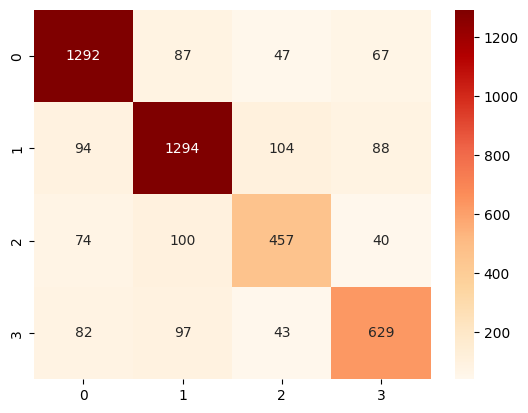

In [43]:
# use classifier for results on test set
classifiers = []
for i in range(class_number):
    clf = LogisticRegression(**best_configuration)
    clf.fit(X_train_counts, y_train == i)
    classifiers.append(clf)
# evaluate each classifier on test set
all_scores=np.zeros((X_test_counts.shape[0], class_number))
for i in range(class_number):
    all_scores[:, i] = classifiers[i].predict_proba(X_test_counts)[:, 1]
y_pred = np.argmax(all_scores, axis=1)
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',cmap="OrRd")

# podejście OvO

In [12]:
# same as above - with Naive Bayes
# create NB classifier for each label

best_configuration = None
best_score = 0
unique_classes = sorted(list(set(y_train.values)))
for config in configurations:
    
    classifiers = {}
    for idx, i in enumerate(unique_classes):
        for j in unique_classes[idx + 1:]:
            
            mask = (y_train.values == i) | (y_train.values == j)
            
            X_train_pair = X_train_counts[mask]
            y_train_pair = (y_train.values[mask] == i).astype(int)
                
            clf = LogisticRegression(**config)
            clf.fit(X_train_pair, y_train_pair)
            classifiers[(i, j)] = clf

    confidence_scores=np.zeros((X_val_counts.shape[0], class_number))
    for (i, j), clf in classifiers.items():
        score_i = clf.predict_proba(X_val_counts)[:, 1]
        score_j = 1-score_i
        confidence_scores[:, i] += score_i
        confidence_scores[:, j] += score_j
    

    y_pred = np.argmax(confidence_scores,axis=1)
    score = np.mean(y_pred == y_val)
    if score>best_score:
        best_score=score
        best_configuration=config
print(f"Best Configuration: {best_configuration}, Best Validation Accuracy: {best_score}")

Best Configuration: {'C': inf, 'l1_ratio': 0, 'max_iter': 1000}, Best Validation Accuracy: 0.7854189336235038


              precision    recall  f1-score   support

           0       0.83      0.89      0.85      1493
           1       0.79      0.87      0.83      1416
           2       0.66      0.40      0.50       163
           3       0.61      0.48      0.54       294
           4       0.69      0.62      0.66       214
           5       0.69      0.53      0.60       164
           6       0.78      0.66      0.72       180
           7       0.74      0.78      0.76       539
           8       0.72      0.33      0.45        80
           9       0.82      0.62      0.70        52

    accuracy                           0.78      4595
   macro avg       0.73      0.62      0.66      4595
weighted avg       0.77      0.78      0.77      4595



<Axes: >

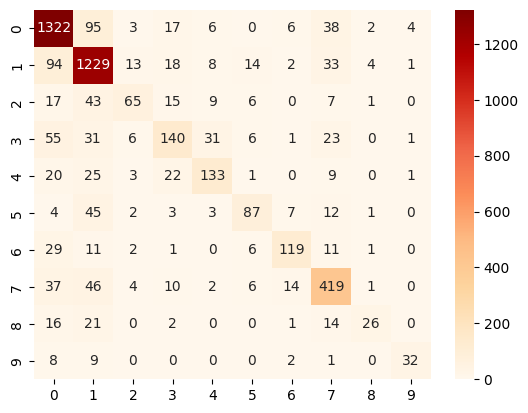

In [13]:
classifiers = {}
for idx, i in enumerate(unique_classes):
    for j in unique_classes[idx + 1:]:
        
        mask = (y_train.values == i) | (y_train.values == j)
        
        X_train_pair = X_train_counts[mask]
        y_train_pair = (y_train.values[mask] == i).astype(int)
            
        clf = LogisticRegression(**best_configuration)
        clf.fit(X_train_pair, y_train_pair)
        classifiers[(i, j)] = clf

confidence_scores=np.zeros((X_test_counts.shape[0], 10))
for (i, j), clf in classifiers.items():
    score_i = clf.predict_proba(X_test_counts)[:, 1]
    score_j = 1-score_i
    confidence_scores[:, i] += score_i
    confidence_scores[:, j] += score_j
y_pred = np.argmax(confidence_scores,axis=1)
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='g',cmap= "OrRd")